FIRST 5 ROWS
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

MISSING VALUES
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

CLEANED DATASET SAVED

PROCESSED DATA SAVED

MODEL TRAINED SUCCESSFULLY

PREDICTIONS
[1 0 2 1 1 0 1 2 1 1]

ACCURACY
1.0

CONFUSION MATRIX
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.

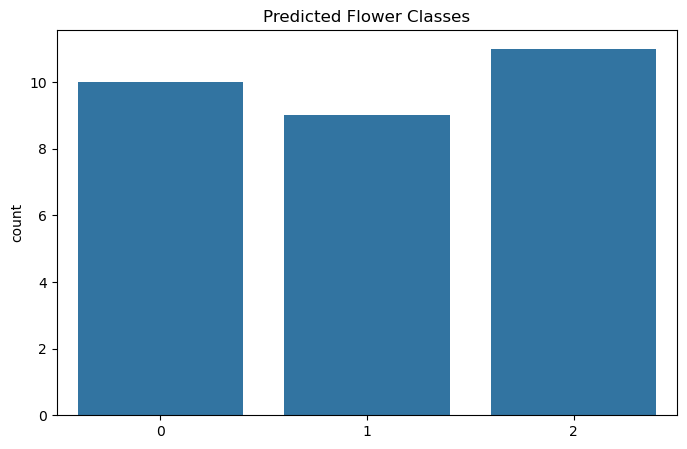


NEW FLOWER PREDICTION
Predicted Class: setosa


In [1]:
# ==========================================
# IRIS FLOWER CLASSIFICATION
# K-NEAREST NEIGHBORS (KNN)
# ==========================================

# ------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# 1. LOAD DATASET
# ==========================================

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

print("FIRST 5 ROWS")
print(df.head())

# ==========================================
# 2. CLEANING
# ==========================================

# Remove duplicates

df = df.drop_duplicates()

# Check missing values

print("\nMISSING VALUES")
print(df.isnull().sum())

# ==========================================
# 3. SAVE CLEANED DATASET
# ==========================================

df.to_csv(
    "../../../datasets/cleaned/iris/cleaned_iris.csv",
    index=False
)

print("\nCLEANED DATASET SAVED")

# ==========================================
# 4. FEATURE SELECTION
# ==========================================

X = df.drop(
    "target",
    axis=1
)

y = df["target"]

# ==========================================
# 5. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# 6. SAVE PROCESSED DATASETS
# ==========================================

X_train.to_csv(
    "../../../datasets/processed/iris/X_train.csv",
    index=False
)

X_test.to_csv(
    "../../../datasets/processed/iris/X_test.csv",
    index=False
)

print("\nPROCESSED DATA SAVED")

# ==========================================
# 7. CREATE MODEL
# ==========================================

model = KNeighborsClassifier(
    n_neighbors=5
)

# ==========================================
# 8. TRAIN MODEL
# ==========================================

model.fit(
    X_train,
    y_train
)

print("\nMODEL TRAINED SUCCESSFULLY")

# ==========================================
# 9. PREDICTIONS
# ==========================================

predictions = model.predict(X_test)

print("\nPREDICTIONS")
print(predictions[:10])

# ==========================================
# 10. EVALUATION
# ==========================================

accuracy = accuracy_score(
    y_test,
    predictions
)

print("\nACCURACY")
print(accuracy)

print("\nCONFUSION MATRIX")
print(confusion_matrix(
    y_test,
    predictions
))

print("\nCLASSIFICATION REPORT")
print(classification_report(
    y_test,
    predictions
))

# ==========================================
# 11. SAVE PREDICTIONS
# ==========================================

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

results.to_csv(
    "../../../datasets/processed/iris/predictions.csv",
    index=False
)

print("\nPREDICTIONS SAVED")

# ==========================================
# 12. VISUALIZATION
# ==========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x=predictions
)

plt.title("Predicted Flower Classes")

plt.show()

# ==========================================
# 13. PREDICT NEW FLOWER
# ==========================================

new_flower = pd.DataFrame({
    "sepal length (cm)": [5.1],
    "sepal width (cm)": [3.5],
    "petal length (cm)": [1.4],
    "petal width (cm)": [0.2]
})

prediction = model.predict(
    new_flower
)

print("\nNEW FLOWER PREDICTION")

print(
    "Predicted Class:",
    iris.target_names[prediction[0]]
)

# ==========================================
# END
# ==========================================